# DeepONet Data Exploration

This notebook explores the dataset generated for training a DeepONet. Targets include potential (phi), velocity (u, v), and pressure (p).

## 1. Load the Dataset

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

dataset_path = "../dataset_deeponet.npz"
data = np.load(dataset_path, allow_pickle=True)

print("Keys in NPZ:", data.files)

Keys in NPZ: ['sdf_sensors', 'bc_sensors', 'phi_targets', 'velocity_targets', 'pressure_targets', 'mesh_coords', 'mesh_triangles', 'metadata']


## 2. Summarize Metadata & Performance

We can see basic simulation info and performance profiles.

In [38]:
metadata = data['metadata']
df = pd.DataFrame(list(metadata))
display(df.head())

print("\nAverage FEM Solve Time: {:.4f}s".format(df['fem_solve_sec'].mean()))

,naca,alpha,n_nodes,mesh_gen_sec,fem_solve_sec,post_process_sec
0,0012,-5.000000,1858,0.750935,0.108049,0.030371
1,0012,-2.777778,1858,0.191453,0.053817,0.032644
2,0012,-0.555556,1858,0.181002,0.053337,0.030215
3,0012,1.666667,1858,0.185872,0.053923,0.031410
4,0012,3.888889,1858,0.182418,0.052040,0.029105



Average FEM Solve Time: 0.0575s


## 3. Deep Dive into Data Structures

In [39]:
idx = 0
coords = data['mesh_coords'][idx].astype(np.float64)
triangles = data['mesh_triangles'][idx].astype(np.int64)
sdf = data['sdf_sensors'][idx].astype(np.float64)
bc = data['bc_sensors'][idx].astype(np.float64)

print(f"--- Mesh structure for simulation {idx} ---")
print(f"Mesh Coordinates shape: {coords.shape} (N_nodes, 2)")
print(f"Mesh Triangles shape: {triangles.shape} (N_tri, 3)")

print(f"\n--- Sensor structure ---")
print(f"SDF Sensors shape: {sdf.shape} (Matches 32x32 grid)")
print(f"BC Sensors shape: {bc.shape} (Values on outer boundary)")

--- Mesh structure for simulation 0 ---
Mesh Coordinates shape: (1858, 2) (N_nodes, 2)
Mesh Triangles shape: (3358, 3) (N_tri, 3)

--- Sensor structure ---
SDF Sensors shape: (1024,) (Matches 32x32 grid)
BC Sensors shape: (100,) (Values on outer boundary)


## 4. Visualizing Mesh vs Sensor Grid (Global & Local Views)

The SDF sensors provide geometry details (even inside the airfoil), while the BC sensors capture the inlet conditions far away.

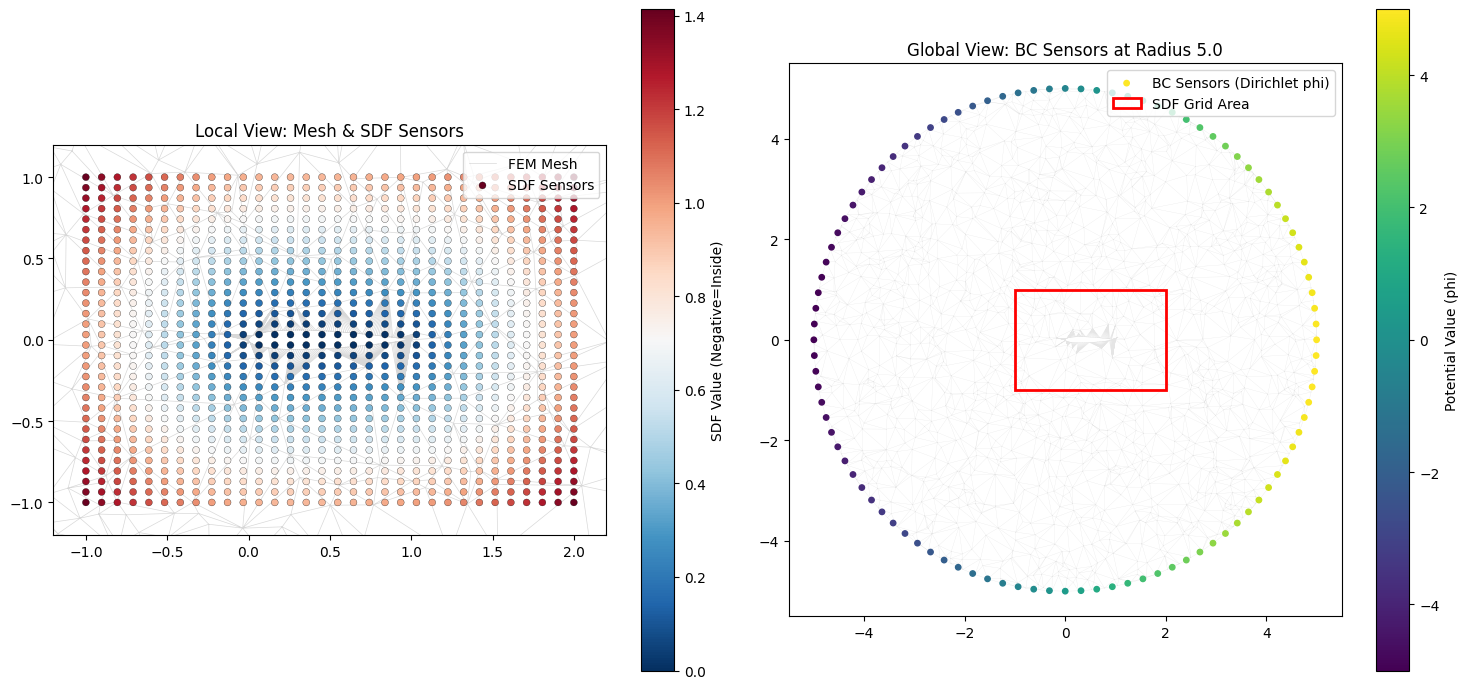

In [40]:
fig = plt.figure(figsize=(15, 7))

# Local view (Near Airfoil)
ax1 = fig.add_subplot(1, 2, 1)
ax1.triplot(coords[:, 0], coords[:, 1], triangles, color='gray', lw=0.5, alpha=0.3, label='FEM Mesh')

gx = np.linspace(-1.0, 2.0, 32)
gy = np.linspace(-1.0, 1.0, 32)
GX, GY = np.meshgrid(gx, gy)
sc1 = ax1.scatter(GX, GY, c=sdf, cmap='RdBu_r', s=25, edgecolor='black', lw=0.2, label='SDF Sensors')
plt.colorbar(sc1, ax=ax1, label='SDF Value (Negative=Inside)')

ax1.set_aspect('equal')
ax1.set_xlim(-1.2, 2.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_title("Local View: Mesh & SDF Sensors")
ax1.legend(loc='upper right')

# Global view (Farfield Conditions)
ax2 = fig.add_subplot(1, 2, 2)
ax2.triplot(coords[:, 0], coords[:, 1], triangles, color='gray', lw=0.2, alpha=0.2)

theta = np.linspace(0, 2*np.pi, 100, endpoint=False)
bx, by = 5.0 * np.cos(theta), 5.0 * np.sin(theta)
sc2 = ax2.scatter(bx, by, c=bc, cmap='viridis', s=15, label='BC Sensors (Dirichlet phi)')
plt.colorbar(sc2, ax=ax2, label='Potential Value (phi)')

# Draw the bounding box of the SDF sensors to show their relative scale
rect = plt.Rectangle((-1, -1), 3, 2, fill=False, color='red', lw=2, label='SDF Grid Area')
ax2.add_patch(rect)

ax2.set_aspect('equal')
ax2.set_title("Global View: BC Sensors at Radius 5.0")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Continuous Field Visualization

Visualizing the physical results (Potential, Velocity, Pressure) as smooth fields using the mesh connectivity.

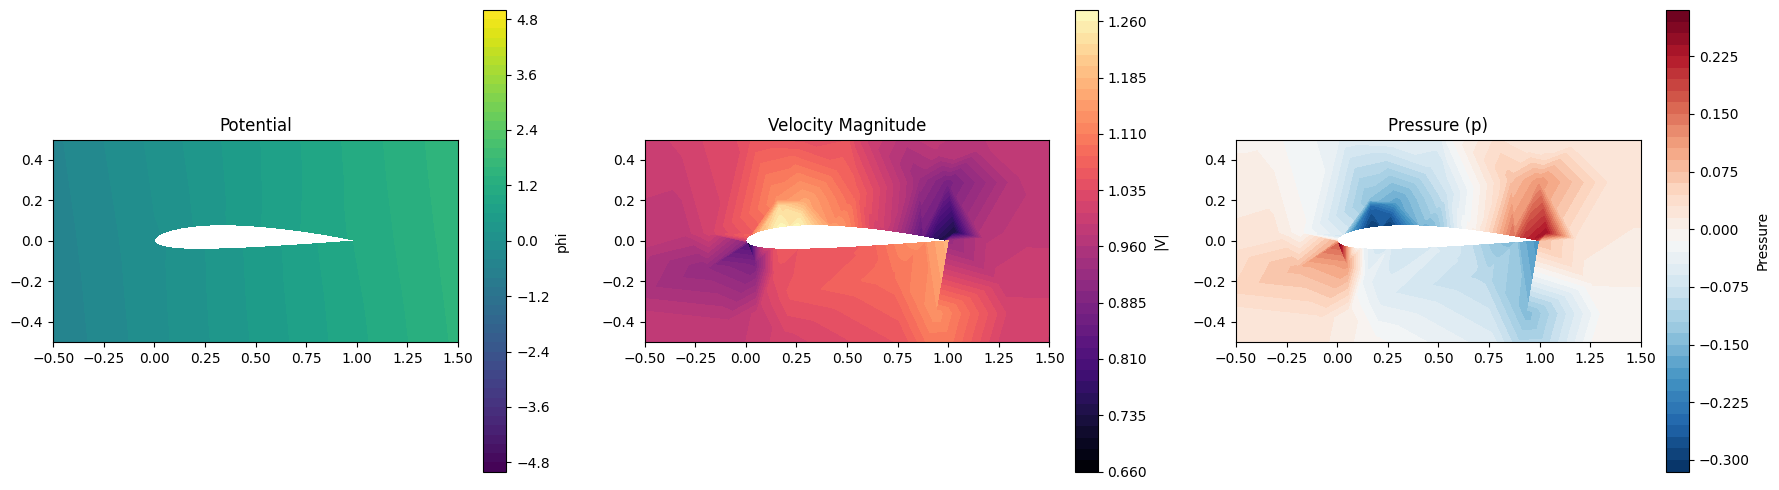

In [41]:
idx = 25
c = data['mesh_coords'][idx].astype(np.float64)
t = data['mesh_triangles'][idx].astype(np.int64)
phi = data['phi_targets'][idx].astype(np.float64)
vel = data['velocity_targets'][idx].astype(np.float64)
pres = data['pressure_targets'][idx].astype(np.float64)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].tricontourf(c[:, 0], c[:, 1], t, phi, levels=50, cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='phi')
axes[0].set_title("Potential")

v_mag = np.linalg.norm(vel, axis=1)
im1 = axes[1].tricontourf(c[:, 0], c[:, 1], t, v_mag, levels=50, cmap='magma')
plt.colorbar(im1, ax=axes[1], label='|V|')
axes[1].set_title("Velocity Magnitude")

im2 = axes[2].tricontourf(c[:, 0], c[:, 1], t, pres, levels=50, cmap='RdBu_r')
plt.colorbar(im2, ax=axes[2], label='Pressure')
axes[2].set_title("Pressure (p)")

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()

## 5. DeepONet Training for Potential (phi)

We define a DeepONet architecture to predict the potential field. 
- **Branch Nets**: Takes the SDF grid (geometry) and BC sensors (inlet conditions).
- **Trunk Net**: Takes the $(x, y)$ coordinates.
- **Output**: The dot product of Branch and Trunk outputs.

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import time
from tqdm.notebook import tqdm

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class DeepONetDataset(Dataset):
    def __init__(self, data, sim_indices):
        # Pre-cast to avoid object-dtype issues in torch.tensor
        self.sdf = [data['sdf_sensors'][i].astype(np.float32) for i in sim_indices]
        self.bc = [data['bc_sensors'][i].astype(np.float32) for i in sim_indices]
        self.coords = [data['mesh_coords'][i].astype(np.float32) for i in sim_indices]
        self.phi = [data['phi_targets'][i].astype(np.float32) for i in sim_indices]
        
        self.mapping = []
        for sim_idx in range(len(sim_indices)):
            for node_idx in range(len(self.coords[sim_idx])):
                self.mapping.append((sim_idx, node_idx))
                
    def __len__(self):
        return len(self.mapping)
        
    def __getitem__(self, idx):
        sim_idx, node_idx = self.mapping[idx]
        return (
            torch.from_numpy(self.sdf[sim_idx]),
            torch.from_numpy(self.bc[sim_idx]), 
            torch.from_numpy(self.coords[sim_idx][node_idx]),
            torch.from_numpy(self.phi[sim_idx][node_idx:node_idx+1])
        )

# Split simulations into train and validation (80/20)
num_sims = data['sdf_sensors'].shape[0]
indices = np.arange(num_sims)
np.random.shuffle(indices)
train_idx = indices[:int(0.8*num_sims)]
val_idx = indices[int(0.8*num_sims):]

train_dataset = DeepONetDataset(data, train_idx)
val_dataset = DeepONetDataset(data, val_idx)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")


Using device: cpu
Train samples: 148640
Val samples: 37160


### 5.1 Model Definition

We use a DeepONet with two branches (one for geometry, one for boundary conditions).

In [43]:
class DeepONet(nn.Module):
    def __init__(self, sdf_dim, bc_dim, trunk_dim, p=128):
        super().__init__()
        
        # Branch 1: Geometry (SDF)
        self.branch_sdf = nn.Sequential(
            nn.Linear(sdf_dim, 256),
            nn.ReLU(),
            nn.Linear(256, p)
        )
        
        # Branch 2: Boundary Conditions
        self.branch_bc = nn.Sequential(
            nn.Linear(bc_dim, 128),
            nn.ReLU(),
            nn.Linear(128, p)
        )
        
        # Trunk: Coordinates
        self.trunk = nn.Sequential(
            nn.Linear(trunk_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, p),
            nn.Tanh()
        )
        
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, sdf, bc, trunk_input):
        # Combining branches (here by addition or concatenation)
        b1 = self.branch_sdf(sdf)
        b2 = self.branch_bc(bc)
        b = b1 + b2 # Merged branch representation
        
        t = self.trunk(trunk_input)
        
        # Inner product
        out = torch.sum(b * t, dim=1, keepdim=True) + self.bias
        return out

model = DeepONet(sdf_dim=1024, bc_dim=100, trunk_dim=2, p=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

### 5.2 Training with Profiling

We train for a few epochs and measure the time.

In [44]:
epochs = 20
train_losses = []
val_losses = []

start_train = time.time()

for epoch in tqdm(range(epochs), desc='Training'):
    model.train()
    running_loss = 0.0
    for sdf, bc, trunk, target in train_loader:
        sdf, bc, trunk, target = sdf.to(device), bc.to(device), trunk.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(sdf, bc, trunk)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * sdf.size(0)
    
    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for sdf, bc, trunk, target in val_loader:
            sdf, bc, trunk, target = sdf.to(device), bc.to(device), trunk.to(device), target.to(device)
            output = model(sdf, bc, trunk)
            loss = criterion(output, target)
            val_running_loss += loss.item() * sdf.size(0)
            
    val_loss = val_running_loss / len(val_dataset)
    val_losses.append(val_loss)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

end_train = time.time()
training_time = end_train - start_train
print(f"\nTraining completed in {training_time:.2f} seconds")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DeepONet Training History')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

## 6. Inference and Comparison

We predict the field for a single validation case and compare it with the FEM result.

In [ ]:
# Pick a validation simulation
test_sim_idx = val_idx[0]
print(f"Testing on Simulation Index: {test_sim_idx}")

sdf_test = torch.tensor(data['sdf_sensors'][test_sim_idx].astype(np.float32)).unsqueeze(0).to(device)
bc_test = torch.tensor(data['bc_sensors'][test_sim_idx].astype(np.float32)).unsqueeze(0).to(device)
coords_test = torch.tensor(data['mesh_coords'][test_sim_idx].astype(np.float32)).to(device)
phi_target_test = data['phi_targets'][test_sim_idx].astype(np.float64)
triangles_test = data['mesh_triangles'][test_sim_idx].astype(np.int64)

# Profile Inference Time
start_inf = time.time()
with torch.no_grad():
    n_nodes = coords_test.shape[0]
    sdf_batch = sdf_test.repeat(n_nodes, 1)
    bc_batch = bc_test.repeat(n_nodes, 1)
    phi_pred = model(sdf_batch, bc_batch, coords_test).cpu().numpy().flatten()
end_inf = time.time()
inference_time = end_inf - start_inf

fem_time = df.loc[test_sim_idx, 'fem_solve_sec']
print(f"DeepONet Inference Time: {inference_time:.6f}s")
print(f"FEM Solve Time: {fem_time:.6f}s")
print(f"Speedup: {fem_time/inference_time:.2f}x")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

c_nodes = data['mesh_coords'][test_sim_idx]

v_min, v_max = min(phi_target_test.min(), phi_pred.min()), max(phi_target_test.max(), phi_pred.max())

tc1 = axes[0].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, phi_target_test, levels=50, cmap='viridis', vmin=v_min, vmax=v_max)
axes[0].set_title(f"FEM Potential (Simulation {test_sim_idx})")
axes[0].set_aspect('equal')
plt.colorbar(tc1, ax=axes[0])

tc2 = axes[1].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, phi_pred, levels=50, cmap='viridis', vmin=v_min, vmax=v_max)
axes[1].set_title("DeepONet Potential")
axes[1].set_aspect('equal')
plt.colorbar(tc2, ax=axes[1])

plt.tight_layout()
plt.show()

# Scatter plot for values
plt.figure(figsize=(6,6))
plt.scatter(phi_target_test, phi_pred, alpha=0.3, s=10)
plt.plot([v_min, v_max], [v_min, v_max], 'r--')
plt.xlabel("FEM Phi")
plt.ylabel("DeepONet Phi")
plt.title("Correlation Plot: FEM vs DeepONet")
plt.grid(True)
plt.show()


## 7. Inferring Velocity and Pressure

From the predicted potential $\phi$, we can calculate velocity $\mathbf{v} = \nabla \phi$ and pressure $p = p_\infty + \frac{1}{2}\rho(v_\infty^2 - |\mathbf{v}|^2)$.

Since the mesh is unstructured, we can use numerical gradients or finite element shape functions.

In [ ]:
def calculate_velocity_unstructured(coords, triangles, phi):
    from matplotlib.tri import Triangulation, LinearTriInterpolator
    triObj = Triangulation(coords[:, 0], coords[:, 1], triangles)
    interp = LinearTriInterpolator(triObj, phi)
    # We need to handle internal nodes (inside airfoil) carefully if they were included, 
    # but FEM solver usually only has nodes outside.
    (grad_x, grad_y) = interp.gradient(coords[:, 0], coords[:, 1])
    return np.stack([grad_x, grad_y], axis=1)

# Calculate inferred velocity
vel_pred = calculate_velocity_unstructured(c_nodes, triangles_test, phi_pred)
vel_target = data['velocity_targets'][test_sim_idx].astype(np.float64)

# Calculate Pressure (Bernoulli)
v_mag_pred_sq = np.sum(vel_pred**2, axis=1)
v_mag_pred = np.sqrt(v_mag_pred_sq)
p_pred = 0.5 * (1.0 - v_mag_pred_sq)
p_target = data['pressure_targets'][test_sim_idx].astype(np.float64)
v_mag_target = np.linalg.norm(vel_target, axis=1)

# Visualization: Velocity Magnitude
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
v_lims = [min(v_mag_target.min(), v_mag_pred.min()), max(v_mag_target.max(), v_mag_pred.max())]
tc1 = axes[0].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, v_mag_target, levels=50, cmap='plasma', vmin=v_lims[0], vmax=v_lims[1])
axes[0].set_title("FEM Velocity Magnitude")
axes[0].set_aspect('equal')
plt.colorbar(tc1, ax=axes[0])

tc2 = axes[1].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, v_mag_pred, levels=50, cmap='plasma', vmin=v_lims[0], vmax=v_lims[1])
axes[1].set_title("DeepONet Inferred Velocity")
axes[1].set_aspect('equal')
plt.colorbar(tc2, ax=axes[1])
plt.suptitle("Velocity Field Comparison", fontsize=16)
plt.show()

# Visualization: Pressure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
p_lims = [min(p_target.min(), p_pred.min()), max(p_target.max(), p_pred.max())]
tc1 = axes[0].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, p_target, levels=50, cmap='RdBu_r', vmin=p_lims[0], vmax=p_lims[1])
axes[0].set_title("FEM Pressure")
axes[0].set_aspect('equal')
plt.colorbar(tc1, ax=axes[0])

tc2 = axes[1].tricontourf(c_nodes[:, 0], c_nodes[:, 1], triangles_test, p_pred, levels=50, cmap='RdBu_r', vmin=p_lims[0], vmax=p_lims[1])
axes[1].set_title("DeepONet Inferred Pressure")
axes[1].set_aspect('equal')
plt.colorbar(tc2, ax=axes[1])
plt.suptitle("Pressure Field Comparison", fontsize=16)
plt.show()

## 8. Quantitative Benchmarking & Surface Error Analysis

We now aggregate performance across the entire validation set, calculating the Mean Squared Error (MSE) for all fields and specifically focusing on the airfoil surface where accuracy is most critical.

In [ ]:
from shapely.geometry import Point, Polygon

def parse_naca4(code):
    m = int(code[0]) / 100.0
    p = int(code[1]) / 10.0
    t = int(code[2:4]) / 100.0
    return m, p, t

def gen_naca4(code, chord=1.0, n_chord=120):
    m, p, t = parse_naca4(code)
    beta = np.linspace(0, np.pi, n_chord)
    x = 0.5 * (1 - np.cos(beta))
    y_c, dyc_dx = np.zeros_like(x), np.zeros_like(x)
    mask = x <= p
    if p != 0:
        y_c[mask] = m*(2*p*x[mask] - x[mask]**2)/p**2
        y_c[~mask] = m*(1 - 2*p + 2*p*x[~mask] - x[~mask]**2)/(1-p)**2
        dyc_dx[mask] = 2*m*(p-x[mask])/p**2
        dyc_dx[~mask] = 2*m*(p-x[~mask])/((1-p)**2)
    y_t = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)
    theta = np.arctan(dyc_dx)
    x_u, y_u = x - y_t*np.sin(theta), y_c + y_t*np.cos(theta)
    x_l, y_l = x + y_t*np.sin(theta), y_c - y_t*np.cos(theta)
    upper = np.column_stack([x_u, y_u])[::-1]
    lower = np.column_stack([x_l, y_l])[1:]
    return np.vstack([upper, lower]) * chord

results = []
for idx in tqdm(val_idx, desc="Benchmarking Validation Set"):
    # Load case data
    meta = data['metadata'][idx]
    naca_code = meta['naca']
    coords = data['mesh_coords'][idx].astype(np.float32)
    triangles = data['mesh_triangles'][idx].astype(np.int64)
    phi_true = data['phi_targets'][idx].astype(np.float32)
    vel_true = data['velocity_targets'][idx].astype(np.float32)
    p_true = data['pressure_targets'][idx].astype(np.float32)
    
    sdf_input = torch.tensor(data['sdf_sensors'][idx].astype(np.float32)).unsqueeze(0).to(device)
    bc_input = torch.tensor(data['bc_sensors'][idx].astype(np.float32)).unsqueeze(0).to(device)
    coords_input = torch.from_numpy(coords).to(device)
    
    # Inference
    t0 = time.time()
    with torch.no_grad():
        n_nodes = coords.shape[0]
        phi_pred_case = model(sdf_input.repeat(n_nodes, 1), bc_input.repeat(n_nodes, 1), coords_input).cpu().numpy().flatten()
    inf_time = time.time() - t0
    
    # Derivatives for velocity/pressure
    vel_pred_case = calculate_velocity_unstructured(coords, triangles, phi_pred_case)
    p_pred_case = 0.5 * (1.0 - np.sum(vel_pred_case**2, axis=1))
    
    # Identify surface nodes
    airfoil_pts = gen_naca4(naca_code)
    poly = Polygon(airfoil_pts)
    dists = np.array([Point(p).distance(poly) for p in coords])
    surface_mask = dists < 0.01 # Tolerance for "on surface"
    
    # Errors
    case_res = {
        'idx': idx,
        'inf_time': inf_time,
        'fem_time': meta['fem_solve_sec'],
        'phi_mse': np.mean((phi_true - phi_pred_case)**2),
        'vel_mse': np.mean((vel_true - vel_pred_case)**2),
        'p_mse': np.mean((p_true - p_pred_case)**2),
        'p_mse_surface': np.mean((p_true[surface_mask] - p_pred_case[surface_mask])**2) if surface_mask.any() else np.nan,
        'vel_mse_surface': np.mean((vel_true[surface_mask] - vel_pred_case[surface_mask])**2) if surface_mask.any() else np.nan
    }
    results.append(case_res)

df_bench = pd.DataFrame(results)
print("Benchmarking Complete.")

In [ ]:
summary = pd.Series({
    'Avg Inference Time (s)': df_bench['inf_time'].mean(),
    'Avg FEM Time (s)': df_bench['fem_time'].mean(),
    'Avg Speedup (x)': (df_bench['fem_time'] / df_bench['inf_time']).mean(),
    'Mean Potential MSE': df_bench['phi_mse'].mean(),
    'Mean Velocity MSE': df_bench['vel_mse'].mean(),
    'Mean Pressure MSE': df_bench['p_mse'].mean(),
    'Mean Surface Velocity MSE': df_bench['vel_mse_surface'].mean(),
    'Mean Surface Pressure MSE': df_bench['p_mse_surface'].mean()
})

print("\n--- Global Performance Metrics (Validation Set) ---")
display(summary.to_frame(name='Value'))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df_bench['p_mse'], bins=10, alpha=0.7, label='Overall')
plt.hist(df_bench['p_mse_surface'], bins=10, alpha=0.7, label='Surface')
plt.title("Pressure MSE Distribution")
plt.xlabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_bench['vel_mse'], bins=10, alpha=0.7, label='Overall')
plt.hist(df_bench['vel_mse_surface'], bins=10, alpha=0.7, label='Surface')
plt.title("Velocity MSE Distribution")
plt.xlabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()